# Intrinsic dimension and feature entanglement in LLMs

**Research question.** Does the intrinsic dimension (ID) of a layer's representations predict
where linear probes succeed — and does the ID peak *discriminate* between linguistic tasks?
And where a linear probe works, is the feature genuinely disentangled, or is linearity just a
sufficient approximation?

This notebook walks through what the pipeline in `idprobe/` does and, more importantly, **why**
each choice was made.

```bash
# the original pipeline — sections 1-8
python run.py extract --model EleutherAI/pythia-160m --tasks sentence_length bigram_shift \
    --n-train 2000 --n-val 500 --n-test 1000 --n-corpus 1000
python run.py id && python run.py probe && python run.py analyze

# added since — sections 9-12
python run.py robustness       # Step 0b: is each ID peak stable across scale?
python run.py conditional-id   # Direction 1: DeltaID = ID(X) - mean_c ID(X | y=c)
python run.py magnitude        # Direction 2: ordinal / regression / norm readouts
```

### How to read this

**Sections 1–8** are the original replication of Cheng et al. They read results from disk and
are left exactly as that run produced them — a record of what we knew at the time, including
the to-do list at the end of §8.

**Sections 9–12** cover everything built since (`docs/NEXT_STEPS.md` Step 0, Direction 1,
Direction 2) and are written so you can **run them with no results on disk at all**. Every
concept is demonstrated on synthetic data whose right answer is known by construction; the
cells that read real results are guarded and skip with a message rather than failing. That is
deliberate — these methods have failure modes that produce *plausible numbers* rather than
errors, so the only way to trust a number is to first watch the estimator on data where you
already know the answer.

The reference point throughout is **Cheng et al., ICLR 2025**, *Emergence of a High-Dimensional
Abstraction Phase in Language Transformers*.

In [1]:
import json, sys, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Works whether the notebook is opened from the repo root or from notebooks/
ROOT = pathlib.Path.cwd()
if not (ROOT / "idprobe").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from idprobe.config import Config, TASKS
from idprobe import intrinsic_dim as ID

MODEL = "Qwen3-0.6B-Base"     # or "pythia-160m"
R = ROOT / "results" / MODEL
print("repo root:", ROOT)
print("tasks:", list(TASKS))
print("results:", sorted(p.name for p in R.glob("*")))

repo root: /Users/myco/Code/id
tasks: ['sentence_length', 'word_content', 'bigram_shift', 'coordination_inversion', 'odd_man_out']
results: ['fig1_id_vs_accuracy.png', 'fig2_linear_vs_mlp.png', 'fig3_id_scaling.png', 'id_accuracy_correlation.csv', 'id_peaks.csv', 'id_profiles.csv', 'id_scaling_curves.json', 'linear_vs_mlp.csv', 'peak_alignment.csv', 'probe_correct.npz', 'probe_results.csv']


---
## 1. What intrinsic dimension measures, and why GRIDE

A layer's representations live in `d_model` dimensions (768 for pythia-160m, 4096 for Qwen3-8B),
but they don't *fill* that space — they lie on a much lower-dimensional manifold. The **intrinsic
dimension** is the dimension of that manifold.

The estimator matters. GRIDE (Denti et al. 2022) works from the ratio of nearest-neighbour distances

$$\mu_i = \frac{r_{i,2k}}{r_{i,k}}$$

which under a locally-uniform density follows a generalised Pareto whose shape depends only on $d$.
Two consequences worth internalising:

1. **It is scale-free.** Only *ratios* of distances enter, so multiplying all representations by a
   constant changes nothing. This is why we must **not** standardise before estimating ID — but
   **must** standardise before training probes (hidden-state norms grow by orders of magnitude
   across layers, which would wreck a fixed learning rate).
2. **`k` sets the scale.** Small `k` probes fine local structure and is noise-sensitive; large `k`
   averages over a wider neighbourhood and washes out curvature. There is no single "right" `k`.

We call DADApy — the reference implementation, by the same group as the paper — rather than
reimplementing it, so numbers stay comparable to the published ones.

In [2]:
# Sanity check: can GRIDE recover a KNOWN dimension?
rng = np.random.default_rng(0)
for d_true in (2, 5, 10, 20):
    X = rng.normal(size=(3000, d_true)) @ rng.normal(size=(d_true, 200))   # d_true-dim plane in 200-d
    s = ID.id_scaling(X, range_max=32, n_points=None)
    print(f"true d={d_true:2d}  ->  estimates across k={list(s['k'])}: {np.round(s['id'], 2)}")

true d= 2  ->  estimates across k=[1, 2, 4, 8, 16]: [2.01 2.03 2.07 2.03 2.01]


true d= 5  ->  estimates across k=[1, 2, 4, 8, 16]: [5.11 5.   5.07 4.94 4.98]


true d=10  ->  estimates across k=[1, 2, 4, 8, 16]: [9.45 9.58 9.29 9.17 8.82]


true d=20  ->  estimates across k=[1, 2, 4, 8, 16]: [17.17 16.23 15.52 15.   14.28]


Two things to notice above:

* The estimate is accurate at low `d` and develops a **downward bias** as `d` grows — a known
  finite-sample property of ratio-based estimators. So ID values are best read *comparatively*
  (across layers) rather than as absolute truths.
* For a genuine manifold the estimate is **flat across `k`** — a plateau. That flatness is the
  diagnostic that the estimate is trustworthy.

---
## 2. The scale-selection trap (a bug this project actually hit)

If you pick the plateau *independently for each layer*, different layers get measured at different
`k` — and you are no longer comparing like with like. The resulting profile has a sawtooth that is
an artefact of the selection procedure, not a property of the model.

`choose_common_scale` fixes **one** `k` for the whole profile. Below: the real scale sweeps from
our run. If the curves never flatten, there is no plateau and the absolute ID is scale-dependent —
which is exactly what happens at small sample sizes.

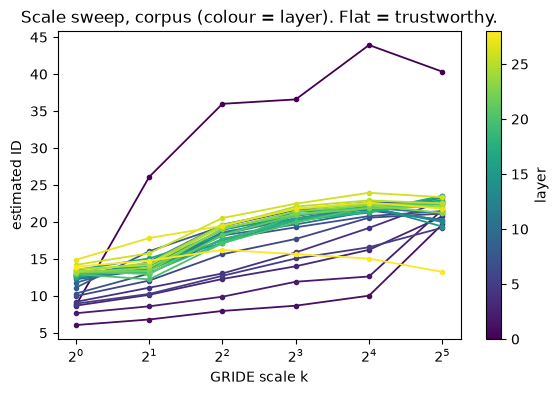

                 k  plateau_found
tag                              
_corpus          8           True
bigram_shift     2          False
sentence_length  2          False

plateau_found=False means no flat region existed and we fell back to a fixed k.


In [3]:
curves = json.loads((R / "id_scaling_curves.json").read_text())
fig, ax = plt.subplots(figsize=(6.5, 4))
keys = sorted((k for k in curves if k.startswith("_corpus/")), key=lambda k: int(k.split("/")[1]))
cmap = plt.get_cmap("viridis")
for i, key in enumerate(keys):
    c = curves[key]
    ax.plot(c["k"], c["id"], color=cmap(i / max(len(keys)-1, 1)), lw=1.3, marker="o", ms=3)
ax.set_xscale("log", base=2); ax.set_xlabel("GRIDE scale k"); ax.set_ylabel("estimated ID")
ax.set_title("Scale sweep, corpus (colour = layer). Flat = trustworthy.")
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, len(keys)-1)), ax=ax, label="layer")
plt.show()

prof = pd.read_csv(R / "id_profiles.csv")
print(prof.groupby("tag")[["k", "plateau_found"]].first())
print("\nplateau_found=False means no flat region existed and we fell back to a fixed k.")

---
## 3. How a sentence becomes a vector

For a **causal** LM, only the final token has attended to the whole sequence. So we take the
**last-token hidden state** at each layer — the same choice Cheng et al. make. Mean-pooling would
average positions with systematically different context windows, mixing "saw 3 tokens" with
"saw 30".

Activations are stored as a `float16` memmap of shape `[n_layers+1, n_sequences, d_model]`.
Layer-major ordering is deliberate: every consumer (ID estimation, probe training) works one layer
at a time, so this keeps those reads contiguous. Index `l` = "after `l` transformer blocks",
so index 0 is the raw embedding.

In [4]:
cfg = Config(model_id=f"x/{MODEL}")
p = cfg.act_path("bigram_shift", "train")
if p.exists():
    mm = np.load(p, mmap_mode="r")
    print("activation tensor:", mm.shape, mm.dtype, f"({mm.nbytes/1e6:.0f} MB)")
    print("layers =", mm.shape[0], "(embedding + transformer blocks)")
else:
    print("no activations on disk for", MODEL, "-- run `python run.py extract` first")

activation tensor: (29, 2000, 1024) float16 (119 MB)
layers = 29 (embedding + transformer blocks)


---
## 4. The ID profile, and the layer-0 trap

Cheng et al.'s central claim is a **distinct mid-network peak** in ID — a "high-dimensional
abstraction phase" — that then *declines* toward the output layers.

One caution the plotting immediately exposes: **layer 0 is the token embedding**, not an
abstraction phase. Its ID reflects the spread of the token vocabulary, and it can be the global
maximum, which silently hijacks any `argmax`-based peak finder. Look at the profile with and
without it.

> **Since fixed.** Layer 0 is now excluded from ID estimation entirely, not just from the peak
> finder — `Config.id_skip_layers = (0,)`. See §9.4. The cell below is kept because it is the
> demonstration of *why*.

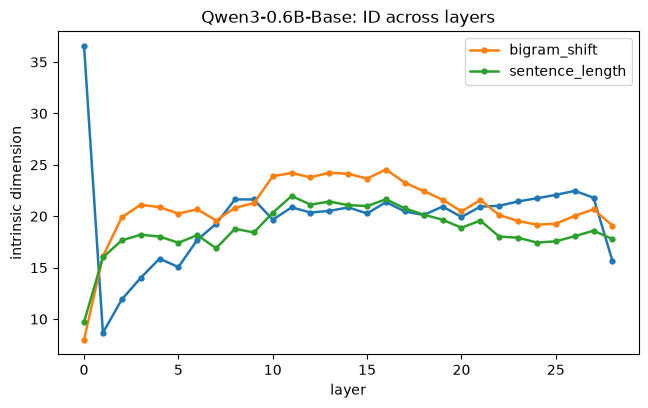

_corpus          argmax WITH L0 =  0   argmax EXCLUDING L0 = 26   (of 28 layers)
bigram_shift     argmax WITH L0 = 16   argmax EXCLUDING L0 = 16   (of 28 layers)
sentence_length  argmax WITH L0 = 11   argmax EXCLUDING L0 = 11   (of 28 layers)


In [5]:
prof = pd.read_csv(R / "id_profiles.csv")
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for tag, g in prof.groupby("tag"):
    g = g.sort_values("layer")
    ax.plot(g.layer, g["id"], marker="o", ms=3.5, lw=1.8, label=tag)
ax.set_xlabel("layer"); ax.set_ylabel("intrinsic dimension"); ax.legend()
ax.set_title(f"{MODEL}: ID across layers")
plt.show()

for tag, g in prof.groupby("tag"):
    v = g.sort_values("layer")["id"].to_numpy(); L = len(v) - 1
    print(f"{tag:16s} argmax WITH L0 = {np.argmax(v):2d}   "
          f"argmax EXCLUDING L0 = {1+np.argmax(v[1:]):2d}   (of {L} layers)")

---
## 5. Probes: linear as the hypothesis, MLP as the control

Under the **linear representation hypothesis**, a disentangled feature should be readable by a
linear map. So:

* a **linear probe** tests whether the feature is linearly decodable;
* a **1x200 MLP probe** (Cheng et al.'s architecture) tests whether *any* smooth function of the
  representation does better.

If the MLP buys nothing, the feature is plausibly linearly encoded. If the MLP wins decisively, the
information is present but **entangled** — recoverable only through a nonlinearity.

The critical design constraint: the two probes must differ **only** in architecture. Same optimiser,
learning rate, weight decay, batch size, patience, seeds, and standardisation. Otherwise a gap
confounds "nonlinearly encoded" with "the MLP got a luckier training run".

We also use **three** splits. Cheng et al. report best-*validation* accuracy over 5 seeds, which is
optimistically biased; here validation drives early stopping and seed selection only, and everything
reported comes from a held-out test split. That is also what makes the McNemar test below valid.

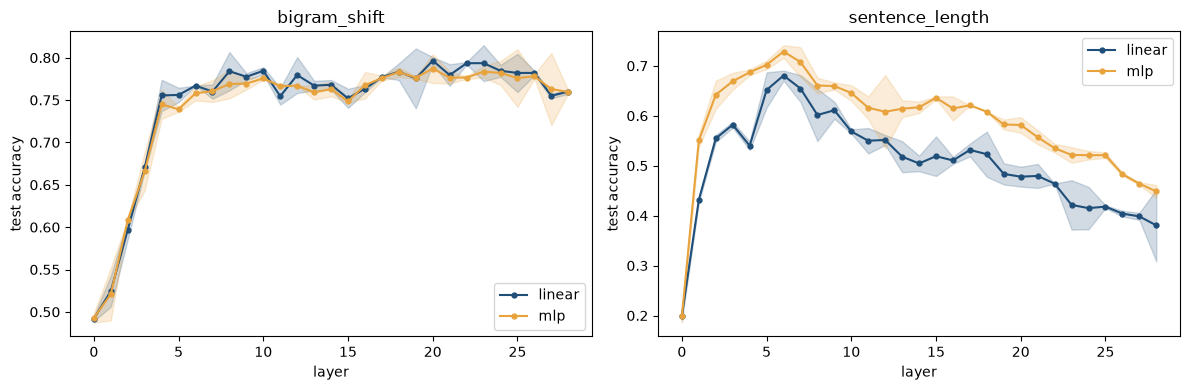

In [6]:
probes = pd.read_csv(R / "probe_results.csv")
tasks = sorted(probes.task.unique())
fig, axes = plt.subplots(1, len(tasks), figsize=(6*len(tasks), 4), squeeze=False)
for ax, t in zip(axes[0], tasks):
    for kind, col in [("linear", "#1f4e79"), ("mlp", "#e8a33d")]:
        g = probes[(probes.task==t)&(probes.kind==kind)].groupby("layer")["test_acc"]
        m, sd = g.mean(), g.std().fillna(0)
        ax.plot(m.index, m.values, marker="o", ms=3.5, color=col, label=kind)
        ax.fill_between(m.index, m-2*sd, m+2*sd, color=col, alpha=.2)
    ax.set_title(t); ax.set_xlabel("layer"); ax.set_ylabel("test accuracy"); ax.legend()
plt.tight_layout(); plt.show()

---
## 6. The statistics, and why a null result is *not* evidence of disentanglement

### McNemar, not a t-test
Both probes are evaluated on **the same test examples**, so the comparison is paired. McNemar's test
conditions on the *discordant* pairs — examples one probe gets right and the other wrong — and
ignores the ones both handle identically. Those concordant examples carry no information about which
classifier is better, and counting them (as an unpaired test does) inflates the variance.

### The asymmetry that matters
A **non-significant** McNemar does not establish linear separability. Absence of evidence is not
evidence of absence: an underpowered layer produces exactly that result. To claim
`linear_sufficient` we require an **equivalence** argument — the upper confidence bound on the MLP's
advantage must fall below a margin small enough to be uninteresting (default 1 accuracy point).
Layers clearing neither bar are honestly `inconclusive`.

### Why `n_test` defaults to 10,000
Run the cell below: it shows the CI on the gap narrowing with sample size. For probes agreeing on
~93% of examples, below roughly 10k test examples you *cannot* establish 1-point equivalence at all,
and every layer returns `inconclusive` no matter how similar the probes really are.

In [7]:
from idprobe.stats import mcnemar_test, classify_layer, gap_confidence_interval
rng = np.random.default_rng(0)
print("two probes agreeing on ~93% of examples (realistic):")
for n in (1000, 2000, 5000, 10000, 20000):
    base = rng.random(n) < 0.82
    a, b = base ^ (rng.random(n) < .04), base ^ (rng.random(n) < .04)
    mc = mcnemar_test(a, b); lo, hi = gap_confidence_interval(mc)
    print(f"  n={n:6d}  gap={mc['acc_gap']:+.4f}  CI=[{lo:+.4f}, {hi:+.4f}]  -> {classify_layer(mc, mc['p_value'])}")

two probes agreeing on ~93% of examples (realistic):
  n=  1000  gap=+0.0060  CI=[-0.0124, +0.0244]  -> inconclusive
  n=  2000  gap=+0.0045  CI=[-0.0074, +0.0164]  -> inconclusive
  n=  5000  gap=+0.0050  CI=[-0.0023, +0.0123]  -> inconclusive
  n= 10000  gap=+0.0001  CI=[-0.0052, +0.0054]  -> linear_sufficient
  n= 20000  gap=-0.0003  CI=[-0.0041, +0.0036]  -> linear_sufficient


In [8]:
# Multiple comparisons: one McNemar per (task, layer). With 5 tasks x 37 layers that is ~185
# tests, so an uncorrected alpha=0.05 would manufacture ~9 spurious "MLP wins" layers.
comp = pd.read_csv(R / "linear_vs_mlp.csv")
print(comp.groupby(["task", "verdict"]).size().to_string())
print()
print(comp[["task","layer","acc_linear","acc_mlp","acc_gap","p_value","q_value","verdict"]]
      .round(4).to_string(index=False))

task             verdict            
bigram_shift     inconclusive           18
                 linear_sufficient      10
                 nonlinear_advantage     1
sentence_length  linear_sufficient       1
                 nonlinear_advantage    28



           task  layer  acc_linear  acc_mlp  acc_gap  p_value  q_value             verdict
   bigram_shift      0       0.493    0.495    0.002   0.7266   0.8899   linear_sufficient
   bigram_shift      1       0.531    0.532    0.001   1.0000   1.0000        inconclusive
   bigram_shift      2       0.593    0.609    0.016   0.2864   0.4615        inconclusive
   bigram_shift      3       0.672    0.674    0.002   0.9284   0.9791        inconclusive
   bigram_shift      4       0.749    0.751    0.002   0.9161   0.9791        inconclusive
   bigram_shift      5       0.759    0.738   -0.021   0.0444   0.0831   linear_sufficient
   bigram_shift      6       0.767    0.761   -0.006   0.5898   0.8144        inconclusive
   bigram_shift      7       0.757    0.756   -0.001   1.0000   1.0000        inconclusive
   bigram_shift      8       0.792    0.775   -0.017   0.0754   0.1367   linear_sufficient
   bigram_shift      9       0.776    0.772   -0.004   0.7434   0.8899        inconclusi

---
## 7. Are we reproducing Cheng et al.?

Their testable claims, and what our small-scale runs show. **Be sceptical of this table**: our runs
use a 160M/0.6B model on 1–2k sequences, against their 6.5–8B models on 10k sequences averaged over
multiple corpora. Several mismatches are expected purely from scale.

In [9]:
# Cheng et al.'s profile: ID rises out of the embeddings to a mid-network peak,
# then COMPRESSES toward the output layers. Quantify that shape for each run.
# NOTE: layer 0 is the token embedding, not an abstraction phase -- exclude it.
rows = []
for m in ("pythia-160m", "Qwen3-0.6B-Base"):
    f = ROOT / "results" / m / "id_profiles.csv"
    if not f.exists():
        continue
    prof = pd.read_csv(f)
    pr = pd.read_csv(ROOT / "results" / m / "probe_results.csv")
    for tag in ("sentence_length", "bigram_shift"):
        v = prof[prof.tag == tag].sort_values("layer")["id"].to_numpy()
        L = len(v) - 1
        pk = 1 + int(np.argmax(v[1:]))                       # exclude embedding layer
        acc = pr[(pr.task == tag) & (pr.kind == "linear")].groupby("layer")["test_acc"].mean()
        rows.append({
            "model": m, "task": tag, "n_layers": L,
            "ID_peak_layer": pk, "rel_depth": round(pk / L, 2),
            "ID_peak": round(v[pk], 1), "ID_final": round(v[-1], 1),
            "post_peak_decline_%": round(100 * (v[-1] - v[pk]) / v[pk]),
            "acc_peak_layer": int(acc.idxmax()), "acc_peak": round(acc.max(), 3),
            "acc_change_after_ID_peak": round(acc.iloc[-1] - acc[pk], 3),
        })
print(pd.DataFrame(rows).to_string(index=False))

          model            task  n_layers  ID_peak_layer  rel_depth  ID_peak  ID_final  post_peak_decline_%  acc_peak_layer  acc_peak  acc_change_after_ID_peak
    pythia-160m sentence_length        12              5       0.42     23.8      22.0                   -8               4     0.540                    -0.117
    pythia-160m    bigram_shift        12              8       0.67     26.6      25.9                   -2               8     0.720                    -0.013
Qwen3-0.6B-Base sentence_length        28             11       0.39     22.0      17.8                  -19               6     0.681                    -0.170
Qwen3-0.6B-Base    bigram_shift        28             16       0.57     24.5      19.1                  -22              20     0.796                    -0.004


Read the `post_peak_decline_%` column first -- it is the paper's central claim in one number.

* **Qwen3-0.6B-Base**: ID compresses **-19%** (`sentence_length`) and **-22%** (`bigram_shift`)
  after its mid-network peak. That is the abstraction phase.
* **pythia-160m**: only **-8%** and **-2%**. Essentially no post-peak compression.

The phase is *scale-dependent*, which is consistent with Cheng et al. -- their own size ablation
only goes down to Pythia-2.8B, and they report the peak is absent in untrained models. A 160M model
appears to sit below the threshold at which the phase emerges.

Now the probing claim. Compare `acc_change_after_ID_peak` between the two tasks on Qwen3-0.6B:

* `sentence_length` (**surface**): accuracy peaks at L6, *before* the ID peak at L11, then collapses
  **-0.170** across the phase (0.681 -> 0.381). Surface information is destroyed by abstraction.
* `bigram_shift` (**syntax**): accuracy climbs to 0.796 at L20 and is flat after the ID peak
  (**-0.004**). Syntactic information survives and crests inside the high-ID region.

That is precisely Cheng et al.'s Figure 5: surface-form probes decline through the peak, syntactic
and semantic probes attain their maximum within it.

### Verdict, claim by claim

| Cheng et al. claim | Qwen3-0.6B-Base | pythia-160m |
|---|---|---|
| ID is `O(10)`, orders of magnitude below `d_model` | 8–24 vs 1024 ✔ | 5–28 vs 768 ✔ |
| Distinct **mid-network ID peak** | L11 / L16 (rel. depth 0.39 / 0.57) ✔ | L5 / L8, but weak |
| **Compression after the peak** | −19% / −22% ✔ | −8% / −2% ✘ |
| Surface probes **degrade** through the peak | −0.170 ✔ | −0.117 ✔ |
| Syntactic probes **crest inside** the peak | −0.004, max at L20 ✔ | −0.013 ✔ |
| Peak absent in untrained models | not tested | not tested |

**We are reproducing Cheng et al. at 0.6B**, on both the geometric claim and the probing claim.
At 160M the probing contrast still holds but the ID phase does not — the profile rises and
plateaus rather than peaking and compressing.

Two caveats that keep this preliminary:

1. **Sample size.** 1–2k sequences, against their 10k averaged over 5 partitions and 3 corpora. The
   scale sweeps in section 2 show no plateau at this n, so absolute ID values are unreliable — the
   *shape* is what reproduces, not the numbers.
2. **The `_corpus` profile is still broken by layer 0.** On the generic Pile corpus the last token
   is an arbitrary token, so its embedding-layer ID (36.6) is the global maximum and hijacks
   `find_peak`. The per-task profiles above do not have this problem because a sentence's last token
   is usually punctuation. Exclude layer 0 before trusting any corpus-level peak statistic.

---
## 8. What we said to change before the full run

*(Written before sections 9–12 existed. §9 scores each item against what actually landed.)*

* **Exclude layer 0 from `find_peak`.** On the generic corpus the embedding layer is the global ID
  maximum and produces nonsense peak statistics (`ID peak L0 vs acc peak L20`). The per-task
  profiles are unaffected, which is why this went unnoticed until the corpus baseline was plotted.
* **`n_corpus` back to 10,000** to match the paper and get genuine plateaus in the scale sweeps.
* **Keep `n_test` at 10,000** — the equivalence test needs it (section 6).
* **Add the untrained-model control.** Cheng et al. report the peak is *nonexistent* in untrained
  models. A randomly-initialised Qwen3 is the cheapest strong falsification test available, and
  given the 160M result it directly probes where the phase emerges.
* **Correlation p-values need depth.** The shift-permutation null has only `n_layers - 1` distinct
  shifts, so at 13 layers the finest achievable p is ~0.08 and at 29 layers ~0.035. At 37 layers
  (Qwen3-8B) it stops binding.
* **Run the remaining three tasks.** `word_content` (surface, 1000-way) and `coordination_inversion`
  / `odd_man_out` (semantics) are what turn a two-point contrast into Cheng et al.'s full picture.

---
# Part II — what was built after §8

Everything from here on was added following `docs/NEXT_STEPS.md`. Three blocks:

| | | |
|---|---|---|
| **§9** | Step 0 | prerequisites — make the existing result trustworthy before extending it |
| **§10** | Direction 1 | class-conditional ID: measure entanglement in ID's own units |
| **§11** | Direction 2 | is `sentence_length` a *magnitude* rather than an entangled feature? |

Direction 3 in that document (sparse autoencoders) was **cut and is not implemented** — see §12.

---
## 9. Step 0 — making the existing result trustworthy

Step 0 exists because of one uncomfortable observation: **the per-task ID peak was not stable.**
Under the old scale mechanics, four of five 0.6B tasks moved their peak between k=2 and k=64. A
peak that moves when you change the measurement scale by one step is not a finding, and no amount
of extension work on top of it would be either. So before anything new was measured, three things
had to happen.

Scoring the §8 to-do list:

| §8 item | what landed |
|---|---|
| Exclude layer 0 from `find_peak` | went further — layer 0 is never *estimated* (§9.4) |
| `n_corpus` back to 10,000 | `Config.n_corpus = 10_000`, `corpus_seq_len = 20` |
| Keep `n_test` at 10,000 | `Config.n_test = 10_000`, unchanged |
| Add the untrained-model control | `--random-init` with its own results tag (§9.3) |
| Correlation p-values need depth | **not fixed** — still `n_layers - 1` shifts. Direction 1 exists partly so the headline no longer depends on it |
| Run the remaining three tasks | all five are in `Config.tasks`; `word_content` is still excluded from ΔID, but on arithmetic rather than by name (§10.5) |

One further change nobody had asked for, and a prerequisite for the rest: **one k per corpus, with
tasks borrowing it** (§9.4).

That also settled which corpus to run by default. `Config.corpora` is now **`bookcorpus` alone** —
the corpus Conneau et al. drew all five probing sets *from*, so it is the baseline the tasks can be
compared against directly, and it is already the corpus whose scale they borrow. `pile` and
`wikitext` are still wired up, but they answer a different question — *is the ID profile
domain-specific, or a property of this text?* — and each costs its own extraction plus two more tags
to sweep: `python run.py extract --corpora bookcorpus pile wikitext`.

In [ ]:
# Locate results. Sections 9-12 all degrade gracefully when nothing is on disk.
NEW_OUTPUTS = ("peak_robustness.csv", "conditional_id.csv", "magnitude.csv")

def pick_results(prefer=MODEL):
    """A results dir that actually has the Part II outputs, else `prefer`, else None.

    Part II may well have been run on a different model from the one §1-8 reports,
    so this prefers whichever directory can actually answer the cells below, and
    falls back to `prefer` only when nothing has Part II outputs at all.
    """
    root = ROOT / "results"
    if not root.exists():
        return None
    have = [d for d in sorted(root.iterdir())
            if d.is_dir() and any((d / f).exists() for f in NEW_OUTPUTS)]
    if have:
        # most Part II outputs wins; `prefer` breaks a tie, then name for determinism
        return sorted(have, key=lambda d: (-sum((d / f).exists() for f in NEW_OUTPUTS),
                                           d.name != prefer, d.name))[0]
    fallback = root / prefer
    return fallback if fallback.is_dir() else None

R2 = pick_results()
if R2 is None:
    print("no Part II results on disk — every cell below still runs on synthetic data,\n"
          "and the ones that read real results will say so and skip.")
else:
    print(f"Part II results directory: {R2.relative_to(ROOT)}\n")
    for f in NEW_OUTPUTS:
        print(f"  {'OK  ' if (R2 / f).exists() else 'MISS'}  {f}")

### 9.1 Step 0a — the bug that motivated the guards

`Qwen3-1.7B-Base`'s `bigram_shift/train.npy` was silently overwritten with a **10,000-row**
extraction while every other task used 2,000. Nothing crashed. But ID is strongly sample-size
dependent (you will watch that happen in §10.1), and the probes had five times the training data,
so that task's numbers were quietly incomparable to its siblings.

The fix was to re-run the stages that consumed it. The *lesson* is in the code: a row-count
mismatch between activations and labels now raises, in three separate places, because this class
of bug produces plausible numbers rather than an error.

| where | guards against |
|---|---|
| `conditional_id.conditional_id` | `len(X) != len(y)` — a task caught mid-re-extraction has a new label file beside an old, shorter activation file. Fancy-indexing would raise something obscure several frames down |
| `run.stage_conditional_id` | same check before any work starts, so the task is skipped with a reason rather than half-computed |
| `run._raw_magnitude` | regenerated splits vs the saved labels — see §11.1 |

Labels are written *before* the activation memmap is filled, which is exactly why the mismatch is
detectable at all.

In [ ]:
# The guard, fired on purpose. This is what a mid-extraction task now looks like.
from idprobe.conditional_id import conditional_id

try:
    conditional_id(np.zeros((100, 5)), np.zeros(90, dtype=int), k=2)
except ValueError as e:
    print("ValueError:", e)

### 9.2 Step 0b — a peak that moves is not a finding

`python run.py robustness` computes nothing new. It reads what `run.py id` already wrote and asks
one question, which is Cheng et al.'s own Figure C.2 criterion:

> **does the peak layer survive halving and doubling k?**

`intrinsic_dim.scale_robustness` pulls the ID profile at the scale below, at, and above the chosen
one — a 4× span — and `stage_robustness` reports how far the peak travels across it. `stable` means
within one layer. Anything else, and the "peak" you were about to build on is an artefact of the
scale choice.

Three other columns come from `table_c1_scales.csv` and matter as much:

| column | reads as |
|---|---|
| `k_if_alone` / `borrowed_k_ratio` | what this dataset *would* have chosen for itself, vs the k it borrows from the corpus (§9.4). A large ratio means the shared scale is nowhere near where this task measures itself |
| `median_spread` | the relative spread of the flattest window in the scale sweep. `has_plateau` is `< 0.10` |
| `has_plateau` | **without a plateau the ID estimate is scale-dependent at every scale** — the absolute number means little and only the shape is worth reading (§2) |

In [ ]:
# Step 0b results, if the stage has been run.
f = (R2 / "peak_robustness.csv") if R2 else None
if f and f.exists():
    rob = pd.read_csv(f)
    cols = [c for c in ("tag", "k_chosen", "peak_half", "peak_chosen", "peak_double",
                        "peak_range", "stable", "k_if_alone", "borrowed_k_ratio",
                        "median_spread", "has_plateau") if c in rob.columns]
    print(rob[cols].to_string(index=False))
    print(f"\n{int(rob.stable.sum())}/{len(rob)} tags keep their peak within one layer "
          f"across a 4x span of k.")
else:
    print("no peak_robustness.csv — run `python run.py id` then `python run.py robustness`")

### 9.3 Step 0c — the untrained-model control

Cheng et al. report the ID peak is **absent in untrained models**. We had never run it, and it is
the cheapest falsification the pipeline admits: if a randomly-initialised model still shows a peak,
the peak belongs to the architecture or to our extraction, not to anything the model learned.

`--random-init` builds the model from its config instead of the checkpoint. Same architecture, same
tokenizer, same extraction path — **only the weights differ**, which is what makes it a control
rather than a different experiment.

The one detail worth pointing at: the control gets its own `model_tag`, so it cannot overwrite or be
confused with the trained run. They would otherwise land in exactly the same paths.

```bash
python run.py extract --model Qwen/Qwen3-1.7B-Base --random-init --no-shuffled --no-tasks
python run.py id      --model Qwen/Qwen3-1.7B-Base --random-init --reference-corpus pile
```

`--no-tasks` because the control only needs the corpus profile — 10k sequences of 20 tokens, against
40k of up to 128 for the five tasks.

### 9.4 The two quiet changes everything else rests on

**Layer 0 is never estimated.** Not "excluded from the peak finder" — never computed.
`Config.id_skip_layers = (0,)`, and skipped layers get `intrinsic_dim.empty_sweep`: a NaN-filled
sweep *with the correct grid shape*, so positions in a profile still equal layer numbers and every
downstream consumer can index by layer without tracking an offset.

Why so strong a measure? Layer 0 is the raw embedding of the **last** token, and SentEval sentences
overwhelmingly end in the same punctuation — a 2,000-sentence split can collapse to about **five
distinct vectors**. Identical points give a zero k-th neighbour distance and an undefined ratio.
That is not a corner case at layer 0; it is the norm.

**One k per corpus, and tasks borrow it.** This is the change that makes any comparison legitimate.
Cheng et al. fix one scale per (model, corpus). Conneau et al. built all five SentEval probing sets
from the Toronto Book Corpus, so those are five *views of one corpus*, not five corpora — they get
no scale of their own and borrow `bookcorpus`'s. Two consequences:

1. the count stays at one k per (model, corpus), as in the paper;
2. task ID and the corpus baseline it gets compared against sit on the **same** scale. Comparing
   them at different k would measure the scale difference, not the representations.

`sane` and `shuffled` stay separate on both sides, so a word-order control is never placed on the
same axis as real text. And `stage_id` lets **only the corpus vote on its own scale** — letting the
borrowing tasks' sweeps shift k would reintroduce exactly the task-derived scale this grouping
exists to remove.

In [ ]:
from idprobe.config import MAGNITUDE_TASKS
from idprobe import intrinsic_dim as IDM

cfg0 = Config()
print("layers skipped from ID entirely :", cfg0.id_skip_layers)
print("reference corpus (tasks borrow) :", cfg0.reference_corpus)
print("corpora                         :", cfg0.corpora)
print("magnitude tasks (see §11)       :", list(MAGNITUDE_TASKS))

print("\nuntrained control cannot collide with the trained run:")
print("  trained :", Config(model_id="Qwen/Qwen3-1.7B-Base").model_tag)
print("  control :", Config(model_id="Qwen/Qwen3-1.7B-Base", random_init=True).model_tag)

print("\nwhich scale each tag is measured at:")
for tag in ("bigram_shift", "sentence_length", "bigram_shift__shuffled",
            "_corpus_bookcorpus_sane", "_corpus_pile_sane"):
    print(f"  {tag:26s} -> {IDM.scale_group(tag, cfg0.reference_corpus)}")

# The NaN placeholder that keeps profile positions equal to layer numbers.
print("\nempty_sweep grid:", IDM.empty_sweep(512)["k"], "-> all-NaN ID, correct shape")

---
## 10. Direction 1 — class-conditional ID

### 10.0 The problem it solves

Everything in §1–§7 correlates two curves: a **dataset-level** number (the ID of a whole task's
representations at a layer) against a **feature-level** number (how well one probe direction reads
one label). Those live at different levels of description, and that mismatch is why

* the correlations come out weak,
* they need a shift-permutation null to be interpretable at all (§6), and
* their p-value floor is set by model *depth* — with only `n_layers - 1` distinct shifts, a 13-layer
  model cannot produce a p below ~0.08 no matter what the data does.

Direction 1 removes the mismatch by measuring the feature **in ID's own units**:

$$\Delta\text{ID} \;=\; \text{ID}(X) \;-\; \text{mean}_c\,\text{ID}(X \mid y = c)$$

In words: measure the dimension of the layer's cloud of representations. Then split the cloud by
label, measure each class's cloud separately, and average. The difference is how many dimensions the
label was *using*.

### The geometric intuition

Picture a cloud that genuinely is 4-dimensional, one of whose coordinates is the feature you care
about. Conditioning on a fine-grained label of that coordinate holds it roughly fixed, and what is
left varies in 3 directions. So $\Delta\text{ID} \approx 1$: **the feature cost one dimension.**

Three readings follow:

| $\Delta$ID | reading |
|---|---|
| $\approx 1$ | the feature occupies about one direction — disentangled, in the sense the linear representation hypothesis means |
| $\gg 1$ | pinning the feature collapses the manifold diffusely — it was smeared across many directions |
| $\approx 0$ | conditioning did nothing; the layer does not encode it *at this scale* (but read §10.4 before believing that) |

That is the story in `docs/NEXT_STEPS.md`. Two things had to be true for it to be measurable at all
— §10.1 and §10.2. Two more turned out to be true and **limit what it can be used to argue** —
§10.3 and §10.4. Take them in order; the caveats matter more than the headline.

### 10.1 Guard 1 — matched sample size (without this, nothing works)

$\text{ID}(X \mid y=c)$ is computed on roughly $n/C$ points while $\text{ID}(X)$ uses all $n$. And
**GRIDE is biased downward at small $n$** — fewer points means sparser neighbourhoods and a
systematically smaller estimate.

So a naive $\Delta$ID is mostly measuring *"the conditional estimate saw less data"*.

Run the next cell. It takes one cloud of known dimension and estimates it from fewer and fewer
points. Watch the size of the drift, then compare it to the $\Delta$ID values we are hoping to
detect (around 1). **The artefact is the same size as the signal.**

In [ ]:
from idprobe.conditional_id import id_at_scale

rng = np.random.default_rng(0)
D_TRUE = 8
X_bias = rng.normal(size=(4000, D_TRUE)) @ rng.normal(size=(D_TRUE, 200))  # 8-d plane in 200-d

print(f"one {D_TRUE}-dimensional cloud, GRIDE at k=4, estimated from fewer and fewer points:\n")
for n in (2000, 1000, 500, 250, 125):
    est = [id_at_scale(X_bias[rng.choice(len(X_bias), n, replace=False)], 4, seed=s)
           for s in range(5)]
    print(f"  n={n:5d}   ID = {np.mean(est):5.2f} +/- {np.std(est):.2f}"
          f"   ({np.mean(est) - D_TRUE:+.2f} vs the true {D_TRUE})")

print("\nThe drift from n=2000 to n=125 is about a whole dimension --")
print("which is exactly the size of the DeltaID effect we want to detect.")

**Therefore:** `conditional_id` draws *every* estimate — pooled and conditional alike — at exactly
`n_match` points, defaulting to the smallest class's count. Taking the pooled estimate at the full
$n$ instead would make $\Delta$ID a measure of how much data each estimate saw. `n_boot` independent
subsamples are averaged, because a single draw of a few hundred points is a noisy estimate and the
bootstrap spread is the only thing separating *"conditioning removed a dimension"* from *"this draw
ran low"*.

#### A small function that makes the whole thing possible: `id_at_scale`

`id_scaling` (§1) deliberately **refuses** to estimate when there are fewer points than `range_max`
(512), returning NaN rather than a silently truncated grid — because a layer measured on a shorter
grid is measured at different scales from its neighbours, which corrupts any cross-layer comparison
built on top of it.

But conditioning on a 6-class label leaves a few hundred points per class. The wide sweep would
refuse outright, while the estimate at k=2 is perfectly well defined.

So `id_at_scale(X, k)` asks for a sweep that **ends** at `k` (`range_max = 2k`) and takes its last
entry. GRIDE reads each scale off the $k$-th and $2k$-th neighbour distances *independently*, so
this is numerically identical to indexing `k` out of the full sweep — but the "too few points" guard
now trips at $n \le 2k$ instead of $n \le 512$. `tests/test_new_directions.py` asserts the two agree
to `rel=1e-9`.

### 10.2 Guard 2 — the label-shuffle null

Matching $n$ removes the *bulk* of the bias but not all of it, and it certainly does not tell you how
big a $\Delta$ID is worth reporting. For that, permute the labels.

A permutation keeps the class sizes **exactly**, so it inherits exactly the same small-$n$ estimator
bias — but it carries no real structure. That is the null. We report

* `delta_corrected` $= \Delta\text{ID} - \Delta\text{ID}_{\text{shuffled}}$ — **never** raw $\Delta$ID
* `z` = that, divided by the spread across permutations

There is a free self-check hiding in this. Once $n$ is matched, a shuffled "class" is just a uniform
random subset of the pooled set — **the same distribution the pooled estimate is drawn from** — so
the null's mean is *analytically zero*. A `delta_null_mean` that drifts away from zero does not mean
a real effect appeared; it means the sample-size matching is broken. That is asserted directly in
`tests/test_new_directions.py::test_label_shuffle_null_is_centred_on_zero`.

**One more invariant:** pooled and conditional estimates always use the **same k**. Different k would
reintroduce exactly the scale confound §9.4 exists to remove — the difference would then partly be
measuring the change in neighbourhood size. `run._resolve_task_k` therefore never picks a scale of
its own; it *recovers* the one the `id` stage used (from `table_c1_scales.csv`, then `scales.json`,
with `--cid-k` only for deliberate sensitivity checks).

The next cell is the positive control: a 4-dimensional cloud whose last coordinate is binned into
20 ordered classes. The right answer is known — conditioning should pin that coordinate and leave 3.

In [ ]:
from idprobe.conditional_id import conditional_id, conditional_id_null

def binned_latent(n=3000, d=30, n_latent=4, n_bins=20, seed=0):
    """A continuous coordinate cut into ordered bins — `sentence_length`'s structure."""
    rng = np.random.default_rng(seed)
    basis = np.linalg.qr(rng.normal(size=(d, d)))[0]
    latent = rng.normal(size=(n, n_latent))
    X = latent @ basis[:n_latent]                       # a 4-d cloud living in 30-d
    cuts = np.quantile(latent[:, -1], np.linspace(0, 1, n_bins + 1)[1:-1])
    return X, np.digitize(latent[:, -1], cuts)          # label = which bin of coordinate 4

X_pc, y_pc = binned_latent(n_bins=20)
obs  = conditional_id(X_pc, y_pc, k=4, n_boot=3, seed=0)
null = conditional_id_null(X_pc, y_pc, k=4, n_perm=10, n_boot=3, seed=0)
z = (obs["delta_id"] - null["delta_null_mean"]) / null["delta_null_sd"]

print("POSITIVE CONTROL — 4-d cloud, last coordinate binned into 20 ordered classes\n")
print(f"  matched n            {obs['n_matched']} points for EVERY estimate ({obs['n_classes']} classes)")
print(f"  ID(X)                {obs['id_pooled']:.2f}      <- the true dimension is 4")
print(f"  mean_c ID(X | y=c)   {obs['id_within_mean']:.2f}      <- one coordinate pinned, so ~3")
print(f"  DeltaID              {obs['delta_id']:+.2f}")
print(f"  null (shuffled y)    {null['delta_null_mean']:+.2f} +/- {null['delta_null_sd']:.2f}"
      f"   <- centred on 0, as it must be")
print(f"  z                    {z:+.1f}")

### 10.3 Caveat 1 — $\Delta$ID is **not comparable across tasks with different class counts**

This is the sharpest limitation, it came out of building the test suite, and it constrains what the
measurement can be used to argue.

A label can only remove the dimension it actually varies along. Think about what a **binary** label
does to a continuous coordinate: it says "you are in the top half" — and within that half the
coordinate still varies almost as much as before. Conditioning barely pins anything, so $\Delta$ID
stays near 0. A **20-way** binning of the *same* coordinate pins it tightly, and $\Delta$ID
approaches 1.

The next cell holds the geometry completely fixed and changes only the number of bins.

In [ ]:
print("IDENTICAL geometry and an IDENTICAL encoded coordinate — only the bin count changes:\n")
for c in (2, 5, 10, 20):
    Xc, yc = binned_latent(n_bins=c)
    o = conditional_id(Xc, yc, k=4, n_boot=3, seed=0)
    print(f"  {c:3d} classes   n_match={o['n_matched']:5d}   DeltaID = {o['delta_id']:+.2f}")

print("\nNothing about the representation changed. DeltaID rose anyway.")

**What this costs us.** `NEXT_STEPS` stated a prediction before running: *"$\Delta$ID should be small
and flat for the three syntactic/semantic tasks and larger for `sentence_length`."* Look at the class
counts — `bigram_shift`, `coordination_inversion` and `odd_man_out` have **2** classes;
`sentence_length` has **6**. The cell above says that ordering falls out of cardinality alone. **The
model could do anything at all and the prediction would still "confirm".** It is not a test.

**The label-shuffle null does not rescue this.** It holds cardinality fixed *within* a task — which
is exactly what makes each task's own z-score valid — but the confound lives in the *cross-task*
comparison, where nothing is held fixed.

**What to do instead:** match the class count first, then compare like with like. Threshold
`sentence_length` at its median into two classes and compare *that* against `bigram_shift`. Any
cross-task ΔID comparison in the results that has not done this is partly just reading class counts.

### 10.4 Caveat 2 — $\Delta$ID is **not a separability measure**

GRIDE at scale $k$ only ever looks at a neighbourhood of roughly $2k$ points. Now suppose two classes
sit far apart — further than that neighbourhood's radius. Then every point's neighbours already
belong to its own class. Conditioning changes nothing *locally*, so $\Delta$ID is ≈ 0 — for classes
that any linear probe would separate perfectly.

The next cell makes that concrete: two clusters offset by 40 units, a linear probe at 100%, and
$\Delta$ID reporting nothing.

In [ ]:
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(0)
n, d = 800, 30
cluster_a = rng.normal(size=(n, 3)) @ rng.normal(size=(3, d))
cluster_b = rng.normal(size=(n, 3)) @ rng.normal(size=(3, d)) + 40.0    # far away
X_sep = np.vstack([cluster_a, cluster_b])
y_sep = np.array([0] * n + [1] * n)

acc = LogisticRegression(max_iter=2000).fit(X_sep[::2], y_sep[::2]).score(X_sep[1::2], y_sep[1::2])
o = conditional_id(X_sep, y_sep, k=4, n_boot=3, seed=0)

print("two well-separated clusters, binary label\n")
print(f"  linear probe accuracy   {acc:.3f}   <- trivially separable")
print(f"  DeltaID                 {o['delta_id']:+.2f}   <- reports nothing at all")
print("\nGRIDE at k=4 never looks past its own neighbourhood, and inside every")
print("neighbourhood the label is already constant. Nothing left to condition on.")

**So a near-zero $\Delta$ID is ambiguous** between *"the layer does not encode this"* and *"it encodes
it at a scale coarser than $k$"*. Only the probe accuracy at that layer distinguishes the two.

**Read `delta_corrected` and `probe_acc` together, never $\Delta$ID alone.** Concretely:

| $\Delta$ID | probe accuracy | reading |
|---|---|---|
| ≈ 0 | high | encoded, but at a coarser scale than $k$ — $\Delta$ID is blind here, not negative |
| ≈ 0 | at chance | genuinely not encoded |
| ≈ 1 | high | the interesting case: one dimension's worth of feature, visible locally |
| $\gg 1$ | high | conditioning collapses the manifold diffusely — the entanglement signature |

Taken with §10.3, the honest summary is that $\Delta$ID answers a **narrower** question than the plan
assumed: *does this feature consume a dimension within the local neighbourhood structure GRIDE can
see?* That is still a direction-level quantity in ID's own units, which is the point — but it is not
a drop-in replacement for "how entangled is this feature".

### 10.5 Reading `conditional_id.csv`

`python run.py conditional-id` writes one row per (task, layer). The columns that matter:

| column | what it is |
|---|---|
| `delta_corrected` | $\Delta$ID − null mean. **This is the number to read.** |
| `z` | `delta_corrected` / `delta_null_sd` |
| `id_pooled_sd` | spread of the pooled estimate across the `n_boot` subsamples — the honest **power** indicator. At k=64 on 333 points this is ~2 ID units, which swamps any $\Delta$ID worth reporting. Without it, a z near 0 is indistinguishable from a real absence of effect |
| `id_class_sd`, `id_class0…N` | spread *across classes*. Large means the classes sit on manifolds of genuinely different dimension, so a single `mean_c` summarises them badly — which is why the per-class IDs are written out rather than kept as an intermediate. For a magnitude task this is exactly what happens: short sentences are far lower-dimensional than long ones |
| `n_matched`, `k`, `k_source` | the guards from §10.1–10.2, recorded so a run is auditable |

**`word_content` is skipped — on arithmetic, not by name.** It has 1000 classes and ~25 examples each
even at full scale, and `stage_conditional_id` refuses any task whose smallest class is $\le 2k$,
because a $2k$-th neighbour does not exist. Skipping on the arithmetic means the *reason* travels
with the run rather than living in someone's memory.

**Cost note.** GRIDE is $O(n^2)$. At `n_train=25000` an uncapped 12500/class costs ~7 s per estimate
and hundreds of seconds per layer, so `--cid-n-match` caps it. Because ID is strongly $n$-dependent,
that cap must be held **fixed** across any runs whose $\Delta$ID you intend to compare.

**And a parallelism trap worth knowing about**, because it is the opposite of the usual advice.
DADApy hardcodes `n_jobs` to the machine's core count. That is the right call for the `id` stage —
one sweep over a big matrix — and badly wrong here, where conditioning makes *hundreds of small
sweeps per layer*: four concurrent tasks each spawned ten workers, putting ~40 workers on 10 cores
and driving load average to ~196. So `id_at_scale` defaults to **`n_jobs=1`**, and the stage is meant
to be parallelised **across tasks** instead — one process per task. `id_scaling` takes the same
argument with `None` (DADApy's default) preserved, so the `id` stage is untouched. Results are
identical either way; the small estimates get ~28% faster even uncontended.

That is also why `run._merge_rows` takes a lock and merges rather than overwriting: these stages are
*expected* to be run one task per process at the same time, and a plain read-modify-write would let
the second finisher silently drop the first task's rows.

In [ ]:
# Direction 1 results, if the stage has been run.
f = (R2 / "conditional_id.csv") if R2 else None
if f and f.exists():
    cid = pd.read_csv(f)

    # Per task: where DeltaID peaks, how strong it is, and -- per §10.4 -- what the
    # probe says at that layer, because DeltaID alone cannot be read.
    print("summary (full table is in `cid`)\n")
    for tag, g in cid.groupby("tag"):
        g = g.sort_values("layer")
        best = g.loc[g.delta_corrected.idxmax()]
        line = (f"  {tag:24s} {int(best.n_classes)} classes, k={int(best.k)}, "
                f"n={int(best.n_matched)} | peak dID {best.delta_corrected:+.3f} "
                f"@ L{int(best.layer)} (z={best.z:+.1f})")
        if "probe_acc" in g:
            line += f" | probe {best.probe_acc:.3f}"
        if "id_drop" in g and pd.notna(best.get("id_drop")):
            line += f" | residual drop {best.id_drop:+.2f}"
        print(line)
        # The power check from §10.5: a z near 0 means nothing if the estimator's
        # own spread is larger than the effect being looked for.
        print(f"  {'':24s} pooled-estimate sd across subsamples: "
              f"{g.id_pooled_sd.median():.2f} ID units")

    fig, ax = plt.subplots(figsize=(7.6, 4.4))
    for i, tag in enumerate(sorted(cid.tag.unique())):
        g = cid[cid.tag == tag].sort_values("layer")
        col = plt.get_cmap("tab10")(i % 10)
        ax.plot(g.layer, g.delta_corrected, marker="o", ms=3.6, lw=1.8, color=col,
                label=f"{tag} ({int(g.n_classes.iloc[0])} classes, k={int(g.k.iloc[0])})")
        ax.fill_between(g.layer, -2 * g.delta_null_sd, 2 * g.delta_null_sd,
                        color=col, alpha=0.10, lw=0)
    ax.axhline(0, color="#444", lw=1.0, ls=":")
    ax.set_xlabel("layer"); ax.set_ylabel(r"$\Delta$ID (null-corrected)")
    ax.set_title("Class-conditional ID — shaded: ±2 SD of the label-shuffle null")
    ax.legend(fontsize=8)
    plt.show()
    print("REMEMBER (§10.3): the legend's class counts are a confound BETWEEN tasks,")
    print("not a nuisance parameter. Compare tasks only at matched class count.")
else:
    print("no conditional_id.csv — run `python run.py conditional-id`")

### 10.6 The complementary variant — residual ID

Same question from the other side. Instead of conditioning on the *label*, delete the **probe's own
direction** and see what the manifold's dimension costs:

* if the feature really is one linear direction, removing it should cost about **one** dimension;
* if removing it costs much more, the probe direction was **entangled** with others rather than
  sitting in a private subspace.

`_residual_row` trains a linear probe at the layer, hands its weights to
`conditional_id.residual_id`, and records `id_full_std → id_residual` and `id_drop`.

Two details are easy to get wrong, and both are handled explicitly:

**1. Remove a *rank*, not a row count.** A softmax is invariant to adding the same vector to every
class row, so the raw $[C, d]$ weight matrix carries a redundant direction that encodes no decision
information. `_residual_row` centres the rows, leaving the rank-$(C-1)$ contrast subspace that
actually separates classes. `residual_id` then builds its projector from an **SVD truncated at
numerical rank**. A plain QR would hand back $C$ orthonormal columns regardless — the last of them
pure rounding noise — deleting one more dimension than the probe actually uses and inflating the
measured cost. This is the realistic case, not a corner one.

**2. Measure in the space the probe lives in.** Both estimates are taken in the **standardised**
feature space the probe was trained on. GRIDE is invariant to a *global* rescaling, but per-feature
standardisation is not global, so measuring the direction in one space and the manifold in another
would not cancel out.

In [ ]:
from idprobe.conditional_id import residual_id

rng = np.random.default_rng(0)
basis = np.linalg.qr(rng.normal(size=(25, 25)))[0][:6]     # 6 orthonormal directions
X_res = rng.normal(size=(2500, 6)) @ basis                 # a 6-d cloud in 25-d

one = residual_id(X_res, basis[:1], k=4, n_boot=3, seed=0)
# Three rows spanning ONE direction -- what a centred probe weight matrix looks like.
dup = residual_id(X_res, np.vstack([basis[0], basis[0], 2.0 * basis[0]]), k=4, n_boot=3, seed=0)

print("deleting a direction the data actually occupies:\n")
print(f"  1 direction, 1 row    ID {one['id_full']:.2f} -> {one['id_residual']:.2f}"
      f"   drop {one['id_drop']:+.2f}   (n_dirs={one['n_dirs']})")
print(f"  1 direction, 3 rows   ID {dup['id_full']:.2f} -> {dup['id_residual']:.2f}"
      f"   drop {dup['id_drop']:+.2f}   (n_dirs={dup['n_dirs']}, but rank 1)")
print("\nSame cost both times: the projector removes the SPAN, not the row count.")
print("Trusting the row count would delete 3 dimensions and report entanglement")
print("that is purely an artefact of how the weights were written down.")

---
## 11. Direction 2 — is `sentence_length` a magnitude rather than a feature?

### 11.0 The puzzle

`sentence_length` is the one task where the **MLP beats the linear probe almost everywhere** —
28/29 layers at 0.6B, 24/29 at 1.7B. It is the most robust result in the project.

The tempting reading is the one §5 set up: *MLP wins ⇒ the information is there but entangled.*
Except that points the **wrong way**. Superposition stories predict that *abstract* features are the
entangled ones and surface features are easy — and sentence length is as surface as a feature gets.

The alternative explanation has nothing to do with entanglement:

> **Length is a magnitude, not a direction.**

A quantity encoded monotonically — in norm, or along a single direction — is badly served by a
softmax over **unordered** bins, which has to carve 6 separate regions out of the representation. And
it is trivially fixed by one hidden layer. If that is what is happening, "the MLP wins" is a
statement about the **readout geometry**, not about the representation — and the same caution applies
to any magnitude-like probe.

Direction 2 adds readouts that can tell the two explanations apart.

### 11.1 The four readouts

| readout | code | what it isolates |
|---|---|---|
| **ordinal** (ordered logit) | `probes.OrdinalProbe` | supplies the missing **ordering** — one score direction plus $K-1$ learned, ordered cut points |
| **regression** on the raw count | `probes.train_regression_probe` | drops binning entirely; $R^2$ against the actual word count |
| **‖h‖ only** | `probes.norm_baseline` | is the "feature" just magnitude? One input feature |
| **4 scalar summaries** | `probes.scalar_summaries` | ‖h‖, mean, std, max — deliberately **blind to direction** |

**Ordinal mechanics.** $P(y \le j) = \sigma(\theta_j - s)$ with $s = w\cdot x + b$. One score, $K-1$
thresholds. The thresholds are parameterised as a base plus *positive* increments (softplus), so
$\theta$ stays sorted throughout training — unsorted cut points would make the implied bin
probabilities negative. The boundaries are padded with $\pm\infty$ so $P(y \le -1) = 0$ and
$P(y \le K-1) = 1$ fall out of the same expression instead of being special-cased.

**Why the norm baseline includes an MLP.** A single scalar can carry a monotone quantity that a
*linear* softmax over bins still cannot cut correctly, so the norm-only **MLP** is the sharper test
of the magnitude hypothesis and the norm-only linear probe is its floor.

**Which tasks this means anything for.** `MAGNITUDE_TASKS` in `idprobe/config.py` (a module-level mapping, not a
`Config` field) maps a task to the function that
recovers its continuous quantity from the raw sentence. Only `sentence_length` qualifies — its six
bins are word counts 5–8, 9–12, 13–16, 17–20, 21–25, 26–28. Other tasks still get the ordinal and
norm readouts, but there is no regression target, and `figures.figure_magnitude` draws an explicit
*"not a magnitude task"* panel rather than an empty axis — an empty axis invites the reader to see a
flat line at zero, i.e. a measured null, where there is simply no measurement.

**One load-bearing check.** Recovering the raw word counts means regenerating the splits
(`data.prepare_task` is deterministic given `data_seed`, and `extract` wrote rows in exactly that
order). That assumption is checked against the labels saved beside the activations, because a silent
misalignment would attach every sentence's length to some *other* sentence's representation and
produce a confidently wrong $R^2$ rather than an error. Same lesson as §9.1.

**And one trap inside the regression head.** `prepare_data(continuous=True)` standardises the
**target** with train statistics, not just the features. A raw word count averages ~16 while the head
initialises near 0, and at `lr=1e-3` the bias alone cannot cross that gap within the epoch budget —
the probe converges to a constant and reports a large negative $R^2$ that *looks like* "length is not
encoded" but means "it never trained". $R^2$ is invariant to an affine change of target, so the
number reported is exactly the $R^2$ against raw counts.

The next cell builds a representation with the magnitude hypothesis **true by construction**: a word
count encoded monotonically along one direction in 256-d, plus clutter, binned with
`sentence_length`'s own cuts.

In [ ]:
import torch
from scipy import stats as sstats
from idprobe.probes import prepare_data, train_probe, train_regression_probe, norm_baseline

rng = np.random.default_rng(0)
D, N = 256, 12000
CUTS = np.array([8, 12, 16, 20, 25])            # sentence_length's own bin edges

u = rng.normal(size=D); u /= np.linalg.norm(u)  # ONE direction carries the quantity
count = rng.integers(5, 29, size=N).astype(float)             # the "word count"
clutter = rng.normal(size=(N, 12)) @ rng.normal(size=(12, D))  # unrelated structure
H = np.log(count)[:, None] * u * 30.0 + clutter + 0.5 * rng.normal(size=(N, D))
y_mag = np.digitize(count, CUTS)

sl = {"train": slice(0, 8000), "val": slice(8000, 10000), "test": slice(10000, N)}
Xm = {s: H[i].astype(np.float32) for s, i in sl.items()}
Ym = {s: y_mag[i] for s, i in sl.items()}
Tm = {s: count[i] for s, i in sl.items()}
dev = torch.device("cpu")

kw = dict(epochs=200, lr=1e-3, weight_decay=1e-4, batch_size=512, patience=25, hidden=200)
data_m = prepare_data(Xm["train"], Ym["train"], Xm["val"], Ym["val"], Xm["test"], Ym["test"], dev)

print(f"{len(CUTS)+1} ordered bins of a quantity encoded monotonically along ONE direction in {D}-d\n")
for kind in ("linear", "mlp", "ordinal"):
    print(f"  {kind:9s} test accuracy   {train_probe(kind, data_m, seed=1, **kw).test_acc:.4f}")

nb_out = norm_baseline(Xm["train"], Ym["train"], Xm["val"], Ym["val"],
                       Xm["test"], Ym["test"], dev, seed=1, **kw)
print()
for k, v in nb_out.items():
    print(f"  {k:15s} {v.test_acc:.4f}")

rr = train_regression_probe(Xm["train"], Tm["train"], Xm["val"], Tm["val"],
                            Xm["test"], Tm["test"], dev, seed=1, **kw)
rho = sstats.spearmanr(np.linalg.norm(Xm["test"].astype(np.float64), axis=1), Tm["test"]).statistic
print(f"\n  regression R^2 on the raw count   {rr.test_acc:+.4f}   <- the quantity is right there")
print(f"  Spearman(||h||, count)            {rho:+.4f}")

Two things to take from that. The **classification** numbers make the encoding look mediocre, while
$R^2$ against the raw count says the quantity is almost perfectly recoverable — that gap *is* the
finding, and it is why `figure_magnitude` puts the continuous readouts on their own axis instead of
pretending they share a scale with accuracy.

But the MLP still won the classification comparison, and the ordinal probe did **not** close the gap
— even though we *built* this data so that the magnitude hypothesis is true. That is not a failure of
the hypothesis. It is the next section.

### 11.2 The convergence trap — the most important methodological finding here

**The readouts do not converge at the same rate.** The MLP converges fastest. So if you give all
three a budget that is generous for the MLP and tight for the others, the MLP looks like it found
nonlinear structure when all it did was finish training first.

Measured on real data (1.7B, layer 11, `sentence_length`, n=25000):

| budget | linear | MLP | ordinal |
|---|---|---|---|
| 100 epochs | still climbing | **0.7940** (already flat) | still climbing |
| 200 epochs | 0.7614 | 0.7940 | **0.8171** ← overtakes the MLP |

The next cell reproduces that on the synthetic data above. It takes about a minute on CPU. Watch the
MLP stay flat while the other two climb past it.

**Epoch count is not scale-free.** What matters is *gradient steps* = `epochs × n_train / batch`. At
n=25000 the stage defaults (200 epochs, batch 512) give ~9,800 steps; at n=2000 the same settings
give ~800 and undertrain badly — flipping the ordinal probe from winning to losing. Raise
`--mag-epochs` when `n_train` is small. This is why the `magnitude` stage carries **its own**
optimisation budget (`--mag-epochs/--mag-batch/--mag-patience`) and records it in the CSV.

**Two consequences worth internalising:**

1. The `probe` stage (§5) is deliberately left untouched. The linear-vs-MLP *gap* it reports is
   robust to this, because what more training changes is the **ordinal** readout — and therefore the
   *explanation* of the gap, not the gap itself.
2. Both McNemar tests in the magnitude stage compare probes trained under **that stage's** protocol.
   Comparing a converged ordinal probe against the `probe` stage's MLP would measure the protocol,
   not the readout.

In [ ]:
# ~1 minute on CPU. The point is the TREND across budgets, not any single row.
print("gradient steps matter, not epochs; n_train=8000, batch=512\n")
for epochs, patience in ((100, 25), (400, 100), (1200, 300)):
    accs = {kind: train_probe(kind, data_m, seed=1, epochs=epochs, lr=1e-3,
                              weight_decay=1e-4, batch_size=512, patience=patience,
                              hidden=200).test_acc
            for kind in ("linear", "mlp", "ordinal")}
    print(f"  epochs={epochs:5d} (~{epochs * 8000 // 512:6d} steps)   "
          + "   ".join(f"{k}={v:.4f}" for k, v in accs.items()))

print("\nThe MLP barely moves -- it converged first. Under a tight budget it looks")
print("like it found nonlinear structure; given enough steps the ORDINAL readout wins.")
print("On this data we know there is no nonlinear structure to find: we built it.")

### 11.3 The new verdict — `monotonic_encoding`

`stats.classify_layer` gained a fourth verdict, reachable **only** when an ordinal probe is supplied
(`mc_ordinal`, which the `magnitude` stage provides). All four:

| verdict | means |
|---|---|
| `nonlinear_advantage` | the MLP wins **and** an ordered readout does not recover it — the feature really is not linearly decodable |
| **`monotonic_encoding`** | **new.** The MLP beats the *linear* probe, but retains no interesting edge over an *ordinal* one. The quantity is encoded monotonically along a direction and the **binned classifier** was the limitation. A claim about readout geometry, **not** about entanglement |
| `linear_sufficient` | equivalence established: the upper CI on the MLP's advantage falls below `margin` |
| `inconclusive` | neither bar cleared — the honest label, not a failure |

The asymmetry from §6 carries straight over: promotion to `monotonic_encoding` requires an
**equivalence** argument too. The MLP's remaining edge over the ordinal probe must be *bounded below*
`margin` — not merely non-significant. Absence of evidence still is not evidence of absence.

Because the verdict is unreachable without `mc_ordinal`, every result produced before Direction 2 is
unchanged. `tests/test_new_directions.py::test_existing_verdicts_are_unchanged_without_an_ordinal_probe`
pins that.

`magnitude.csv` also carries **`ordinal_closes`** = $(\text{acc}_\text{ordinal} -
\text{acc}_\text{linear}) / (\text{acc}_\text{mlp} - \text{acc}_\text{linear})$ — the share of the
linear→MLP gap that ordering alone accounts for. **Near 1 means the gap was never evidence of
entanglement.**

In [ ]:
# Direction 2 results, if the stage has been run.
f = (R2 / "magnitude.csv") if R2 else None
if f and f.exists():
    mag = pd.read_csv(f)
    cols = [c for c in ("task", "layer", "acc_linear", "acc_mlp", "acc_ordinal",
                        "acc_norm_mlp", "mlp_gap", "ordinal_closes", "regression_r2",
                        "spearman_norm_target", "q_linear_vs_mlp", "verdict")
            if c in mag.columns]
    print(mag[cols].round(4).to_string(index=False))
    print("\nverdicts per task:")
    print(mag.groupby(["task", "verdict"]).size().to_string())
    print(f"\nbudget actually used: {int(mag.epochs.iloc[0])} epochs, "
          f"batch {int(mag.batch_size.iloc[0])}  (§11.2 -- check this before reading anything above)")
else:
    print("no magnitude.csv — run `python run.py magnitude --tasks sentence_length`")

---
## 12. Where this leaves the project

### What is now true that was not before

* **The peak is auditable.** `peak_robustness.csv` says, per task, whether the peak survives a 4×
  span of $k$ and whether a plateau exists at all. A peak that moves is reported as moving (§9.2).
* **Scale is fixed once per corpus**, and tasks borrow the corpus they came from, so task ID and the
  corpus baseline are on the same axis (§9.4).
* **There is an untrained control** that can falsify the whole pipeline in one extraction (§9.3).
* **There is a direction-level measurement**, $\Delta$ID, that does not depend on correlating two
  autocorrelated curves — with two honest limits on what it can claim (§10.3, §10.4).
* **"MLP wins" is no longer automatically "entangled".** The `monotonic_encoding` verdict names the
  alternative, and the ordinal/regression/norm readouts test it (§11).

### What is still open

| question | where it stands |
|---|---|
| Which model carries the headline result? | Qwen3-8B on the H100, or a 0.6B/1.7B/8B sweep that doubles as Cheng et al.'s Figure D.1 |
| Is `word_content` worth rescuing? | needs ~50k training examples to be meaningful at 1000 classes; currently excluded from $\Delta$ID on arithmetic (§10.5) |
| How many corpora? | the default is now `bookcorpus` alone — the corpus SentEval is drawn from, hence the directly comparable baseline. Cheng et al.'s Fig 1 and C.3 average over three; `pile` and `wikitext` are wired up and answer the *domain-specificity* question instead, one extraction each — `--corpora bookcorpus pile wikitext` |
| Correlation p-value floor | **unfixed.** Still `n_layers - 1` shifts (§8). Direction 1 exists partly so the headline need not rest on it |
| Cross-task $\Delta$ID comparison | blocked on matching class counts first (§10.3) |

### What was cut

**Direction 3 (sparse autoencoders) is deferred and not implemented.** There is no `sae` stage, no
all-token extraction path, and `dictionary_learning`/`sae_lens` are not dependencies. The reasoning
in `docs/NEXT_STEPS.md` still stands — ID measures manifold dimension, superposition is a claim about
$N$ features in $d < N$ dimensions under sparsity, and those can move independently — so nothing in
this pipeline currently measures superposition *directly*. It needs its own extraction path (all
token positions, millions of activations) and is H100-only work.

### Running it

```bash
# Step 0 — before trusting anything downstream
python run.py id --model Qwen/Qwen3-1.7B-Base --rechoose
python run.py robustness --model Qwen/Qwen3-1.7B-Base

# Step 0c — the falsification test
python run.py extract --model Qwen/Qwen3-1.7B-Base --random-init --no-shuffled --no-tasks
python run.py id      --model Qwen/Qwen3-1.7B-Base --random-init --reference-corpus pile

# Direction 1 and 2
# one process per task -- see the parallelism note in §10.5; do NOT rely on
# DADApy's internal threading here, and keep --cid-n-match identical across tasks
python run.py conditional-id --model Qwen/Qwen3-1.7B-Base --tasks bigram_shift --cid-n-match 2000
python run.py magnitude      --model Qwen/Qwen3-1.7B-Base --tasks sentence_length

# figures, including dir1_conditional_id.png and dir2_magnitude.png
python run.py figures --model Qwen/Qwen3-1.7B-Base
```

And the tests, which are where the synthetic cells above came from — each builds a case whose right
answer is known by construction, because for these estimators the failure mode is a *plausible
number*, not a crash:

```bash
conda run -n id python -m pytest tests/test_new_directions.py -q
```